[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MarcoBattiato/PH6721-Deep-Learning-with-Python/blob/main/Classes/Class_2/02B-ClassificationAndLogisticRegression.ipynb)

# 02B — Classification and Logistic Regression
(by Marco Battiato. For questions/errors/bugs/typos report, please email at marco.battiato.teaching@gmail.com)

**PH6721 — Deep Learning with Python**

**Class 2, Notebook B — Hour 2**

**Instructor:** Marco Battiato (formerly Nanyang Assistant Professor @ Nanyang Technological University)

**email:**  marco.battiato.teaching@gmail.com

**In Person Classes:**  Wednesday 6:30pm - 9:45pm

**Consultation:** remote consultations are to be arranged by writing to marco.battiato.teaching@gmail.com

Notebook `01C` ended with a question:

> Can we build a model that automatically predicts the species from the measurements?

This notebook answers it. The framework is the one from `02A`; only the target changes, from a
number to a category. Seeing exactly what that change forces us to alter — and what it leaves
untouched — is the point of the hour.

## Learning Objectives

By the end of this notebook, students should be able to:

- state the classification problem, and say how it differs from regression;
- explain why fitting a straight line to 0/1 labels is unsatisfactory;
- describe the logistic function and what it is for;
- write down the logistic regression model and interpret its output as a probability;
- explain where the cross-entropy loss comes from, and why squared error is not used;
- fit a logistic regression with scikit-learn and read its coefficients;
- draw and interpret a decision boundary;
- measure a classifier with accuracy, and say why accuracy alone is not enough;
- recognise data that a linear classifier cannot separate.

# 1. From predicting a number to predicting a category

In `02A` the target was a continuous quantity: an extension in centimetres, a measure of disease
progression. The task was **regression**.

Very often the quantity we want is instead a **category**:

- is this detector event signal, or background?
- is this material stable, or unstable?
- is this tissue sample healthy, or diseased?
- which of three species is this flower?

This is **classification**, and it is the other half of supervised learning.

## 1.1 What changes, and what does not

Look back at the learning loop from `02A` §2.4. Every box is still there:

| Box | Regression | Classification |
|---|---|---|
| Data | $(\mathbf{X}, \mathbf{y})$ | unchanged |
| Model | outputs a number | must output a **probability** |
| Predictions | $\hat{y} \in \mathbb{R}$ | $\hat{p} \in [0, 1]$ |
| Loss | squared error | **cross-entropy** |
| Training | minimise the loss | unchanged |

Only two boxes change. That is the whole of this notebook: what the model must output instead,
and what loss goes with it.

## 1.2 The problem we will use

We return to the Iris dataset from `01C`, and take the harder of the two questions it poses.

`setosa` is trivially separable from the others — a single measurement divides it perfectly, as
the plots in `01C` showed. The interesting pair is **versicolor against virginica**, which overlap.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
iris = pd.read_csv(url)

# Keep the two species that actually overlap.
pair = iris[iris["species"].isin(["versicolor", "virginica"])].copy()

# The target must be numeric: 1 for virginica, 0 for versicolor.
pair["is_virginica"] = (pair["species"] == "virginica").astype(int)

print(pair["species"].value_counts())
pair.head()

species
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal_length,sepal_width,petal_length,petal_width,species,is_virginica
50,7.0,3.2,4.7,1.4,versicolor,0
51,6.4,3.2,4.5,1.5,versicolor,0
52,6.9,3.1,4.9,1.5,versicolor,0
53,5.5,2.3,4.0,1.3,versicolor,0
54,6.5,2.8,4.6,1.5,versicolor,0


Two conventions worth stating, because they hold throughout machine learning.

The target is written as **0 and 1**, not as text. The choice of which class is 1 is arbitrary;
here `virginica` is the **positive class**, and every statement below is relative to that choice.

The two classes are **balanced**, 50 each. That is convenient and, as `01C` noted, unusual. §8
returns to what happens when they are not.

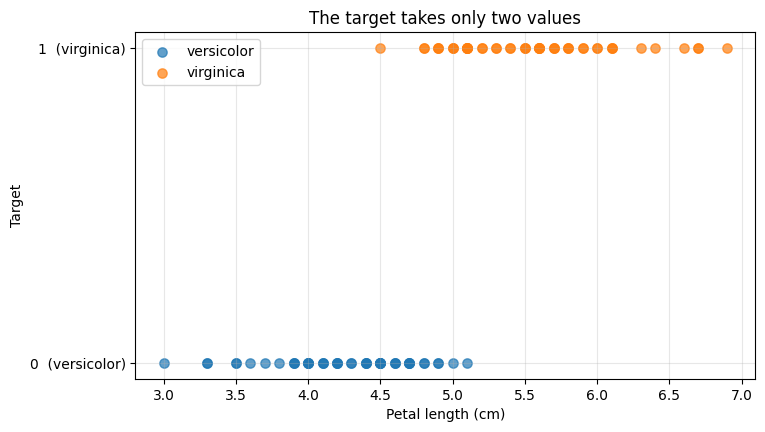

In [2]:
plt.figure(figsize=(8, 4.5))

for name, group in pair.groupby("species"):
    plt.scatter(group["petal_length"], group["is_virginica"],
                s=45, alpha=0.7, label=name)

plt.yticks([0, 1], ["0  (versicolor)", "1  (virginica)"])
plt.xlabel("Petal length (cm)")
plt.ylabel("Target")
plt.title("The target takes only two values")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

The picture already tells us the shape of the problem. Short petals are versicolor, long petals are
virginica, and in between there is a region where both occur. A useful model will have to express
that uncertainty rather than pretend it away.

# 2. Why not just fit a straight line?

We already know how to fit a straight line. The target is a number — 0 or 1 — so nothing stops us
running exactly the least squares fit from `02A`.

The next cell fits a straight line through those 0/1 labels and reports the largest and smallest
values it predicts.

1. What will the line predict for a flower with a very long petal, say 7 cm?
2. What will it predict for a very short one?
3. Are those numbers usable as probabilities?

**Think about your answer before running this cell.**

In [ ]:
from sklearn.linear_model import LinearRegression

X = pair[["petal_length"]]
y = pair["is_virginica"]

linear = LinearRegression().fit(X, y)
predictions = linear.predict(X)

print(f"smallest prediction: {predictions.min():.3f}")
print(f"largest prediction:  {predictions.max():.3f}")
print(f"predictions outside [0, 1]: {((predictions < 0) | (predictions > 1)).sum()} of {len(predictions)}")

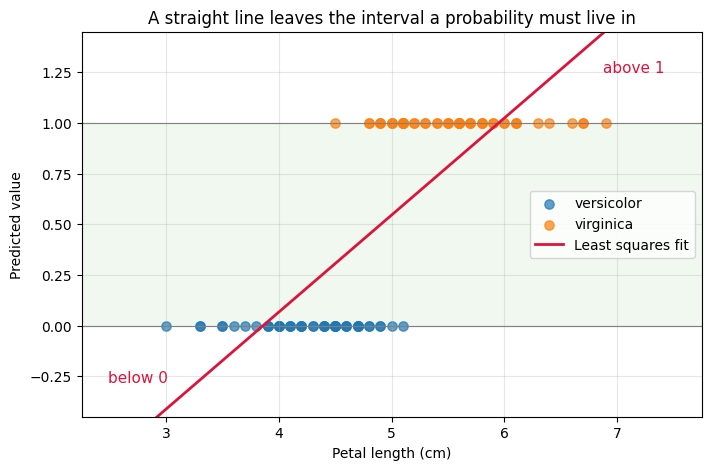

In [4]:
grid = pd.DataFrame({"petal_length": np.linspace(2.5, 7.5, 200)})

plt.figure(figsize=(8, 5))
plt.axhspan(0, 1, color="tab:green", alpha=0.07)
plt.axhline(0, color="grey", linewidth=0.8)
plt.axhline(1, color="grey", linewidth=0.8)

for name, group in pair.groupby("species"):
    plt.scatter(group["petal_length"], group["is_virginica"], s=45, alpha=0.7, label=name)

plt.plot(grid["petal_length"], linear.predict(grid), color="crimson", linewidth=2,
         label="Least squares fit")

plt.text(7.15, 1.25, "above 1", color="crimson", fontsize=11, ha="center")
plt.text(2.75, -0.28, "below 0", color="crimson", fontsize=11, ha="center")

plt.xlabel("Petal length (cm)")
plt.ylabel("Predicted value")
plt.title("A straight line leaves the interval a probability must live in")
plt.ylim(-0.45, 1.45)
plt.grid(alpha=0.3)
plt.legend(loc="center right")
plt.show()

The line does something reasonable in the middle and something meaningless at the edges. Nineteen
of the hundred flowers receive a prediction outside $[0, 1]$, and a prediction of 1.45 or
-0.41 cannot be read as "the probability of virginica".

We could clip the values, but that patches the symptom. The deeper problems are:

- **there is no probability interpretation**, so we cannot say how confident the model is;
- **the fit is dragged by distant points**: a single flower with a very long petal pulls the whole
  line, even though it tells us nothing we did not already know;
- **squared error is the wrong measure** of how wrong a 0/1 prediction is.

What we want is a model whose output is *always* a probability, and which stops being pulled
around once a point is confidently on the right side.

# 3. The logistic function

The fix is to keep the straight line, and then bend its output into $[0, 1]$.

The standard way to do that is the **logistic function**, also called the **sigmoid**:

$$
\sigma(z) \;=\; \frac{1}{1 + e^{-z}}
$$

It takes any real number and returns a value strictly between 0 and 1.

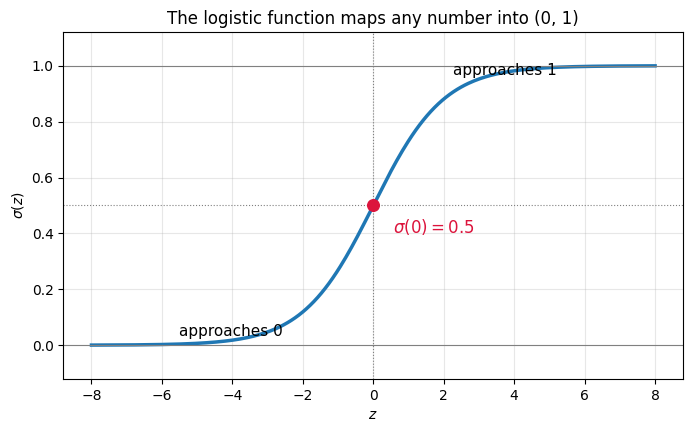

In [5]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


z = np.linspace(-8, 8, 300)

plt.figure(figsize=(8, 4.5))
plt.plot(z, sigmoid(z), linewidth=2.5, color="tab:blue")

plt.axhline(0, color="grey", linewidth=0.8)
plt.axhline(1, color="grey", linewidth=0.8)
plt.axhline(0.5, color="grey", linewidth=0.8, linestyle=":")
plt.axvline(0, color="grey", linewidth=0.8, linestyle=":")
plt.scatter([0], [0.5], s=70, color="crimson", zorder=5)

plt.annotate("$\\sigma(0) = 0.5$", (0, 0.5), textcoords="offset points", xytext=(14, -20),
             fontsize=12, color="crimson")
plt.annotate("approaches 1", (6, 0.9976), textcoords="offset points", xytext=(-95, -6), fontsize=11)
plt.annotate("approaches 0", (-6, 0.0025), textcoords="offset points", xytext=(12, 6), fontsize=11)

plt.xlabel("$z$")
plt.ylabel("$\\sigma(z)$")
plt.title("The logistic function maps any number into (0, 1)")
plt.ylim(-0.12, 1.12)
plt.grid(alpha=0.3)
plt.show()

Three properties matter for what follows.

1. **The output is always a valid probability.** $\sigma(z)$ is strictly between 0 and 1 for every
   finite $z$, so it never has to be clipped.
2. **It is symmetric about $z = 0$**, where it equals exactly 0.5. That point will become the
   decision boundary.
3. **It saturates.** For $|z| > 5$ or so the curve is almost flat. Once a point is confidently
   classified, pushing it further changes the output very little — which is exactly the "stop being
   dragged by distant points" behaviour we wanted.

<div class="alert alert-success">
<b>Mini-exercise 1 — Reading the sigmoid</b><br>
Using the <code>sigmoid</code> function defined above:
<br><br>
1. Compute <code>sigmoid(0)</code>, <code>sigmoid(2)</code> and <code>sigmoid(-2)</code>.<br>
2. What is <code>sigmoid(2) + sigmoid(-2)</code>? Try a few other pairs <code>z</code> and <code>-z</code>. What does this tell you about the shape of the curve?<br>
3. How large must <code>z</code> be before <code>sigmoid(z)</code> exceeds 0.99?
</div>

In [6]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 4. Logistic regression

We now have both pieces. Compute a **score** exactly as in linear regression,

$$
z \;=\; a x + b
$$

and then pass it through the sigmoid to obtain a probability:

$$
\hat{p} \;=\; P(y = 1 \mid x) \;=\; \sigma(a x + b) \;=\; \frac{1}{1 + e^{-(ax + b)}}
$$

That is the whole model. It is called **logistic regression**, which is a slightly unfortunate
name: it is a classification method, not a regression method.

The parameters are still just a slope and an intercept, and they still have to be found by
minimising a loss. What changes is which loss.

Before deriving that loss, here is what the fitted model looks like, so that the target is
concrete. The curve is the estimated probability of virginica at each petal length.

a = 3.591    b = -17.509


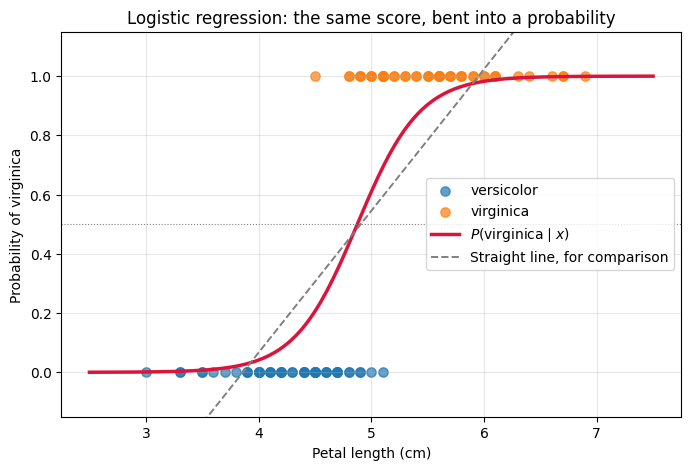

In [7]:
from sklearn.linear_model import LogisticRegression

logistic = LogisticRegression().fit(X, y)

a_hat = logistic.coef_[0, 0]
b_hat = logistic.intercept_[0]
print(f"a = {a_hat:.3f}    b = {b_hat:.3f}")

probabilities = logistic.predict_proba(grid)[:, 1]

plt.figure(figsize=(8, 5))
for name, group in pair.groupby("species"):
    plt.scatter(group["petal_length"], group["is_virginica"], s=45, alpha=0.7, label=name)

plt.plot(grid["petal_length"], probabilities, color="crimson", linewidth=2.5,
         label="$P(\\mathrm{virginica} \\mid x)$")
plt.plot(grid["petal_length"], linear.predict(grid), color="grey", linewidth=1.4,
         linestyle="--", label="Straight line, for comparison")

plt.axhline(0.5, color="grey", linewidth=0.8, linestyle=":")
plt.xlabel("Petal length (cm)")
plt.ylabel("Probability of virginica")
plt.title("Logistic regression: the same score, bent into a probability")
plt.ylim(-0.15, 1.15)
plt.grid(alpha=0.3)
plt.legend(loc="center right", fontsize=10)
plt.show()

Compare the two curves. They agree in the middle, where the data actually change from one species
to the other. They differ where it matters: the straight line keeps going, while the logistic
curve flattens out and stays inside $[0, 1]$.

Note also that the model gives a genuine probability in the overlap region, around 4.5 to 5.5 cm.
It does not claim to know. That is the correct answer there.

# 5. The loss: cross-entropy

Two questions remain: why not simply reuse squared error, and where does the right loss come from.

## 5.1 Why not squared error?

We could measure the fit by $\sum_i (y_i - \hat{p}_i)^2$. Nothing forbids it. But it makes the
optimisation problem much harder.

Recall from `02A` §4.3 that the squared-error loss for a *straight line* was a smooth convex bowl
with exactly one minimum. Putting a sigmoid inside squared error destroys that property.

The next cell draws two loss surfaces over the same parameters $(a, b)$: squared error with a
sigmoid on the left, cross-entropy on the right.

One of them is a clean bowl like the one in `02A`. Which do you expect, and why?

**Think about your answer before running this cell.**

In [ ]:
def scores(a, b, x_values):
    return a * x_values + b


def squared_loss(a, b):
    p = sigmoid(scores(a, b, x_data))
    return np.mean((y_data - p) ** 2)


def cross_entropy_loss(a, b):
    # logaddexp form: numerically stable, no clipping needed
    z = scores(a, b, x_data)
    return np.mean(np.logaddexp(0, z) - y_data * z)


x_data = pair["petal_length"].to_numpy()
y_data = pair["is_virginica"].to_numpy()

a_grid = np.linspace(0.0, 8.0, 120)
b_grid = np.linspace(-45.0, 5.0, 120)
A, B = np.meshgrid(a_grid, b_grid)

squared_surface = np.zeros_like(A)
entropy_surface = np.zeros_like(A)
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        squared_surface[i, j] = squared_loss(A[i, j], B[i, j])
        entropy_surface[i, j] = cross_entropy_loss(A[i, j], B[i, j])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, surface, name in [(axes[0], squared_surface, "Squared error with a sigmoid"),
                          (axes[1], entropy_surface, "Cross-entropy")]:
    contour = ax.contourf(A, B, surface, levels=30, cmap="viridis")
    ax.contour(A, B, surface, levels=12, colors="white", linewidths=0.5, alpha=0.5)
    fig.colorbar(contour, ax=ax, fraction=0.046)
    ax.scatter([a_hat], [b_hat], s=110, color="crimson", edgecolor="white",
               linewidth=1.5, zorder=5, label="fitted parameters")
    ax.set_xlabel("slope a")
    ax.set_ylabel("intercept b")
    ax.set_title(name)
    ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

Both surfaces put their minimum in the same place, marked in red. What differs is everywhere else.

The squared error **saturates**. Over most of the plane it sits at almost exactly its largest
value, and the contours there are so widely spaced that there is effectively no downhill direction
to follow. This is the sigmoid's doing: once it has saturated, moving the parameters barely changes
the predictions, so it barely changes the loss. A search starting anywhere in that yellow region
has almost nothing to go on.

The cross-entropy varies smoothly across its whole range. Wherever a search starts, the surface
tells it which way to move.

Checking the curvature numerically along a slice through the surfaces confirms it: the squared
error has a genuinely negative second derivative, around -0.02, while the cross-entropy stays at
zero to within numerical precision.

This matters because every method from Class 7 onward is trained by walking downhill on a loss
surface. A loss with plateaus and no single basin makes that walk unreliable.

> Squared error with a sigmoid is **not convex**. Cross-entropy is.

## 5.2 Where cross-entropy comes from

There is a better reason than convenience, and it is the argument from `02A` §9 run again.

There we assumed the observations were the model plus **Gaussian** noise, wrote down the
likelihood, took its logarithm, and found that maximising it was exactly minimising the sum of
squares. **Least squares is maximum likelihood under Gaussian noise.**

Here the target is not a noisy real number. It is a coin flip: $y_i$ is either 0 or 1, and the
model supplies the probability $\hat{p}_i$ that it is 1. The right distribution is therefore not
Gaussian but **Bernoulli**:

$$
P(y_i \mid x_i, \boldsymbol{\theta}) \;=\; \hat{p}_i^{\,y_i}\,(1 - \hat{p}_i)^{\,1 - y_i}
$$

Check the two cases: if $y_i = 1$ this is $\hat{p}_i$, and if $y_i = 0$ it is $1 - \hat{p}_i$.
Exactly as it should be.

The observations are independent, so the likelihood of the whole dataset is the product of these
terms, and taking a logarithm turns the product into a sum:

$$
\log P(\mathbf{y} \mid \mathbf{X}, \boldsymbol{\theta})
\;=\; \sum_{i=1}^{n} \Bigl[\, y_i \log \hat{p}_i \;+\; (1 - y_i)\log(1 - \hat{p}_i) \,\Bigr]
$$

Maximising that is minimising its negative, which is the **cross-entropy loss**:

$$
L(\boldsymbol{\theta}) \;=\; -\frac{1}{n}\sum_{i=1}^{n}
\Bigl[\, y_i \log \hat{p}_i \;+\; (1 - y_i)\log(1 - \hat{p}_i) \,\Bigr]
$$

So the two losses are the same idea applied to two different assumptions about the data:

| Target | Assumed distribution | Maximum likelihood gives |
|---|---|---|
| a noisy real number | Gaussian | **squared error** |
| a 0/1 label | Bernoulli | **cross-entropy** |

The choice of loss is not a matter of taste. It follows from what kind of thing the target is.

### What the loss does to a single prediction

Only one of the two terms is ever active, because $y_i$ is 0 or 1. The penalty for one observation
is therefore $-\log \hat{p}$ when the true label is 1, and $-\log(1 - \hat{p})$ when it is 0.

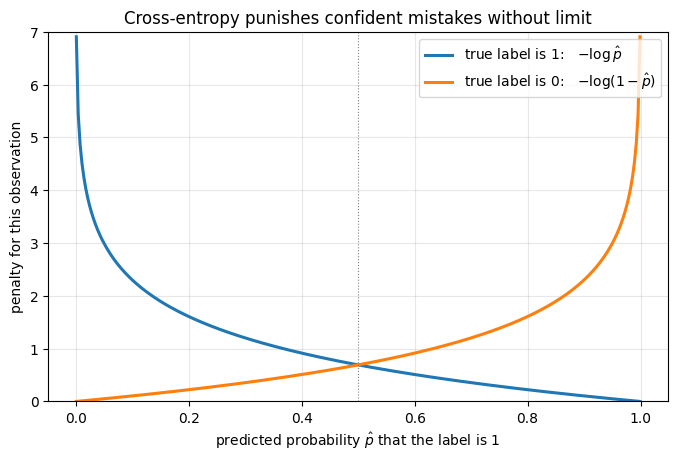

In [9]:
p = np.linspace(0.001, 0.999, 300)

plt.figure(figsize=(8, 4.8))
plt.plot(p, -np.log(p), linewidth=2.2, label="true label is 1:   $-\\log \\hat{p}$")
plt.plot(p, -np.log(1 - p), linewidth=2.2, label="true label is 0:   $-\\log(1 - \\hat{p})$")

plt.axvline(0.5, color="grey", linewidth=0.8, linestyle=":")
plt.xlabel("predicted probability $\\hat{p}$ that the label is 1")
plt.ylabel("penalty for this observation")
plt.title("Cross-entropy punishes confident mistakes without limit")
plt.ylim(0, 7)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Read the blue curve, for an observation whose true label is 1.

Predicting $\hat{p} = 0.9$ costs about 0.11. Predicting 0.5 — admitting ignorance — costs
0.69. Predicting 0.01, that is being confidently wrong, costs 4.6, and the penalty grows
without bound as $\hat{p} \to 0$.

This is the behaviour we want from a probabilistic model. **Being confidently wrong is much worse
than being unsure.** Squared error does not have this property: its worst possible penalty for one
observation is 1, no matter how badly the model was fooled.

<div class="alert alert-success">
<b>Mini-exercise 2 — The cost of confidence</b><br>
Using the two expressions above:
<br><br>
1. An observation has true label 1. Compute the loss for predictions of 0.99, 0.5 and 0.01.<br>
2. Repeat for an observation with true label 0.<br>
3. A model predicts 0.5 for every flower, regardless of its measurements. What is the average loss? Where does that number come from?<br>
4. Why can no model achieve a cross-entropy of exactly zero on data where the classes overlap?
</div>

In [10]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 6. Fitting the model

The scikit-learn interface is the one from `02A`: create, `fit`, `predict`. Only the class name
changes.

> One detail is worth knowing now and then setting aside. `LogisticRegression` does not minimise
> cross-entropy alone: by default `scikit-learn` also adds an **L2 penalty** on the coefficients,
> controlled by the parameter `C`. It is mild, and it changes nothing we conclude in this notebook.
> It does mean that "the model that minimises the loss of §5" is a slight simplification, and that
> the fitted coefficients depend on the scale of the features. Both points are treated properly in
> `03C`.

In [11]:
logistic = LogisticRegression().fit(X, y)

print(f"slope     a = {logistic.coef_[0, 0]:.3f}")
print(f"intercept b = {logistic.intercept_[0]:.3f}")

# Two different questions, two different methods:
print("\nfirst five predicted classes:      ", logistic.predict(X)[:5])
print("first five predicted probabilities:", logistic.predict_proba(X)[:5, 1].round(3))

slope     a = 3.591
intercept b = -17.509

first five predicted classes:       [0 0 1 0 0]
first five predicted probabilities: [0.347 0.206 0.521 0.041 0.271]


The distinction between `predict` and `predict_proba` is worth pausing on.

`predict_proba` returns the probability the model actually computed. `predict` throws most of that
away, returning only which side of 0.5 it fell.

For a scientific application the probability is usually the more useful object. A flower with
$\hat{p} = 0.52$ and one with $\hat{p} = 0.99$ are both reported as virginica by `predict`, and
they are not remotely the same claim.

### Reading the coefficients

The score is $z = ax + b$ with $a = 3.59$ and $b = -17.51$. The slope is positive, so longer petals
push the score up and therefore the probability of virginica up.

The units are less intuitive than in `02A`, where the slope was a physical quantity in cm/N. Here
$a$ is measured in "score per centimetre", and the score is on the scale the sigmoid consumes. A
standard reading is that a one-centimetre increase in petal length multiplies the **odds** of
virginica by $e^{a} = e^{3.59} \approx 36$.

The warning from `02A` §8.4 applies with equal force: with several correlated features, individual
coefficients are unstable and should not be read as effects.

# 7. The decision boundary

To turn a probability into a decision we choose a **threshold**, conventionally 0.5.

Because $\sigma(z) = 0.5$ exactly when $z = 0$, the rule "predict virginica when
$\hat{p} > 0.5$" is the same as the rule "predict virginica when $ax + b > 0$".

With one feature that boundary is a single point:

$$
x^{*} = -\frac{b}{a}
$$

decision boundary at petal length = 4.876 cm


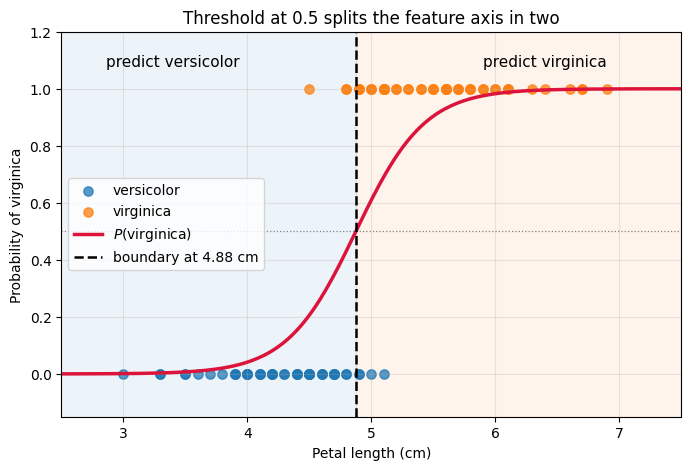

In [12]:
boundary = -logistic.intercept_[0] / logistic.coef_[0, 0]
print(f"decision boundary at petal length = {boundary:.3f} cm")

plt.figure(figsize=(8, 5))
plt.axvspan(2.5, boundary, color="tab:blue", alpha=0.08)
plt.axvspan(boundary, 7.5, color="tab:orange", alpha=0.08)

for name, group in pair.groupby("species"):
    plt.scatter(group["petal_length"], group["is_virginica"], s=45, alpha=0.75, label=name)

plt.plot(grid["petal_length"], logistic.predict_proba(grid)[:, 1],
         color="crimson", linewidth=2.5, label="$P(\\mathrm{virginica})$")
plt.axhline(0.5, color="grey", linewidth=0.9, linestyle=":")
plt.axvline(boundary, color="black", linewidth=1.8, linestyle="--",
            label=f"boundary at {boundary:.2f} cm")

plt.text(3.4, 1.08, "predict versicolor", ha="center", fontsize=11)
plt.text(6.4, 1.08, "predict virginica", ha="center", fontsize=11)

plt.xlabel("Petal length (cm)")
plt.ylabel("Probability of virginica")
plt.title("Threshold at 0.5 splits the feature axis in two")
plt.ylim(-0.15, 1.2)
plt.xlim(2.5, 7.5)
plt.grid(alpha=0.3)
plt.legend(loc="center left", fontsize=10)
plt.show()

## 7.1 Two features

With two features the score becomes $z = a_1 x_1 + a_2 x_2 + b$, and the boundary $z = 0$ is a
**straight line** in the feature plane. With $p$ features it is a flat $(p-1)$-dimensional surface,
a hyperplane — the same geometry as the fitted plane in `02A` §8.1.

This is what makes logistic regression a **linear classifier**: the probability surface is curved,
but the boundary between the decisions is always flat.

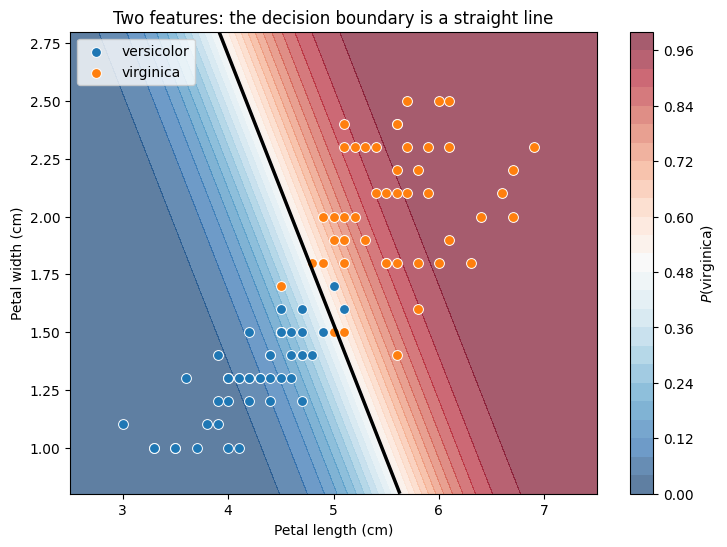

In [13]:
X2 = pair[["petal_length", "petal_width"]]
logistic_2d = LogisticRegression().fit(X2, y)

# Evaluate the model over a grid so the probability can be shaded.
lengths = np.linspace(2.5, 7.5, 300)
widths = np.linspace(0.8, 2.8, 300)
LL, WW = np.meshgrid(lengths, widths)
mesh = pd.DataFrame({"petal_length": LL.ravel(), "petal_width": WW.ravel()})
P = logistic_2d.predict_proba(mesh)[:, 1].reshape(LL.shape)

plt.figure(figsize=(8.5, 6))
shading = plt.contourf(LL, WW, P, levels=25, cmap="RdBu_r", alpha=0.65)
plt.colorbar(shading, label="$P(\\mathrm{virginica})$")
plt.contour(LL, WW, P, levels=[0.5], colors="black", linewidths=2.5)

for name, group in pair.groupby("species"):
    plt.scatter(group["petal_length"], group["petal_width"], s=50,
                edgecolor="white", linewidth=0.7, label=name)

plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("Two features: the decision boundary is a straight line")
plt.legend(loc="upper left")
plt.show()

The colour shows the model's probability, shading smoothly from one class to the other. The black
line is where that probability equals 0.5.

Notice that the boundary is straight even though the shading is curved, and that a handful of
flowers sit on the wrong side of it. Those are the ones the model gets wrong — and with two
overlapping species, some errors are unavoidable.

<div class="alert alert-success">
<b>Mini-exercise 3 — Moving the threshold</b><br>
The threshold does not have to be 0.5.
<br><br>
1. Using <code>predict_proba</code>, classify the flowers with a threshold of 0.9 instead. How many virginica are now missed?<br>
2. Repeat with a threshold of 0.1. How many versicolor are now wrongly called virginica?<br>
3. Describe in one sentence what raising the threshold does.<br>
4. Suppose the classes were "healthy" and "has a serious disease". Which way would you move the threshold, and why?
</div>

In [14]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 8. How good is it?

The obvious measure is **accuracy**: the fraction of flowers classified correctly.

In [15]:
from sklearn.metrics import accuracy_score, confusion_matrix

accuracy_1d = accuracy_score(y, logistic.predict(X))
accuracy_2d = accuracy_score(y, logistic_2d.predict(X2))

print(f"accuracy, petal length only:        {accuracy_1d:.3f}")
print(f"accuracy, length and width:         {accuracy_2d:.3f}")

accuracy, petal length only:        0.930
accuracy, length and width:         0.950


Adding the second measurement takes the model from 93% to 95%. Both are respectable for two
species that genuinely overlap.

But accuracy alone is a poor summary, for a reason that has nothing to do with this dataset.

Suppose we were screening for a disease that affects 1 in 100 patients. A model that ignores its
input entirely and reports "healthy" for everyone achieves **99% accuracy** — and is worthless.
Accuracy is only meaningful relative to the class balance, and it hides *which kind* of mistake the
model makes.

The first step beyond accuracy is to count the four possible outcomes separately.

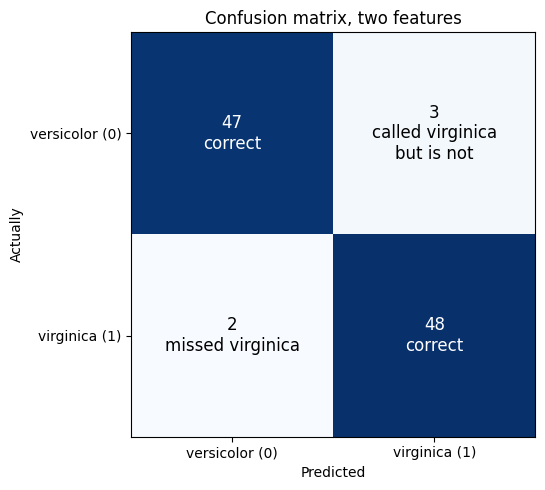

In [16]:
matrix = confusion_matrix(y, logistic_2d.predict(X2))

fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(matrix, cmap="Blues")

labels = ["versicolor (0)", "virginica (1)"]
ax.set_xticks([0, 1])
ax.set_xticklabels(labels)
ax.set_yticks([0, 1])
ax.set_yticklabels(labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actually")
ax.set_title("Confusion matrix, two features")

names = [["correct", "called virginica\nbut is not"],
         ["missed virginica", "correct"]]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{matrix[i, j]}\n{names[i][j]}", ha="center", va="center",
                fontsize=12, color="white" if matrix[i, j] > matrix.max()/2 else "black")

plt.tight_layout()
plt.show()

The two off-diagonal entries are different mistakes, and in most real problems they carry different
costs. Missing a diseased patient is not the same as alarming a healthy one; missing a rare particle
event is not the same as recording a spurious one.

Class 3 develops this properly, with precision, recall, F1 and the ROC curve. For now the point is
only that **one number is not enough**, and that the confusion matrix is where to look first.

# 9. When logistic regression is the wrong tool

The boundary is always flat. When the classes are not separable by a flat boundary, no amount of
fitting will help.

The next cell builds a dataset of two classes arranged as concentric rings: one class in the middle,
the other surrounding it. It then fits a logistic regression.

1. Can a straight line separate these two classes?
2. What accuracy do you expect the model to reach?
3. What would a model that ignored the features entirely achieve?

**Think about your answer before running this cell.**

In [ ]:
rng = np.random.default_rng(0)
n_points = 300

radius = rng.uniform(0, 1, n_points)
angle = rng.uniform(0, 2 * np.pi, n_points)

X_rings = np.column_stack([radius * np.cos(angle), radius * np.sin(angle)])
y_rings = (radius < 0.5).astype(int)          # inner disc is class 1

rings_model = LogisticRegression().fit(X_rings, y_rings)

print(f"accuracy:                     {accuracy_score(y_rings, rings_model.predict(X_rings)):.3f}")
print(f"always guessing the majority:  {max(y_rings.mean(), 1 - y_rings.mean()):.3f}")
print(f"\nfitted coefficients: {rings_model.coef_[0].round(3)}")
print(f"classes it ever predicts: {np.unique(rings_model.predict(X_rings))}")

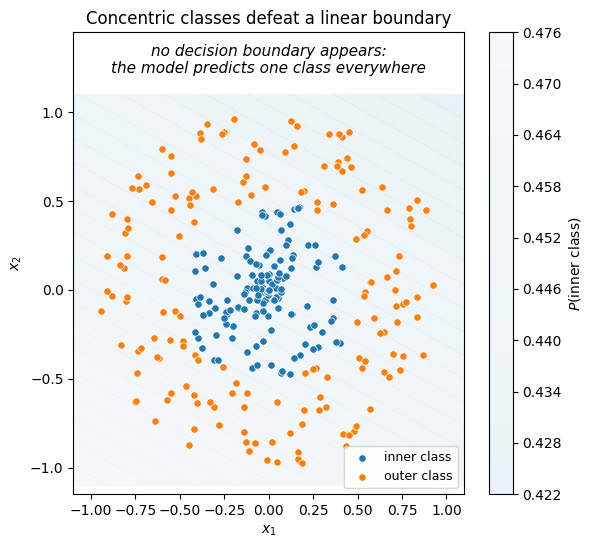

In [18]:
mesh_x, mesh_y = np.meshgrid(np.linspace(-1.1, 1.1, 300), np.linspace(-1.1, 1.1, 300))
P_rings = rings_model.predict_proba(np.column_stack([mesh_x.ravel(), mesh_y.ravel()]))[:, 1]

plt.figure(figsize=(6.5, 6))
shading = plt.contourf(mesh_x, mesh_y, P_rings.reshape(mesh_x.shape), levels=25,
                       cmap="RdBu_r", alpha=0.55, vmin=0, vmax=1)
plt.colorbar(shading, label="$P(\\mathrm{inner\\ class})$")

# There is deliberately no 0.5 contour here: the probability never reaches 0.5.
plt.text(0, 1.22, "no decision boundary appears:\nthe model predicts one class everywhere",
         ha="center", fontsize=11, style="italic")

for value, name in [(1, "inner class"), (0, "outer class")]:
    mask = y_rings == value
    plt.scatter(X_rings[mask, 0], X_rings[mask, 1], s=28,
                edgecolor="white", linewidth=0.5, label=name)

plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Concentric classes defeat a linear boundary")
plt.legend(loc="lower right", fontsize=9)
plt.ylim(-1.15, 1.45)
plt.gca().set_aspect("equal")
plt.show()

The model achieves exactly the accuracy of ignoring the data entirely — and the way it fails is
more interesting than the fact that it does.

Look at the fitted coefficients: both are within a few hundredths of **zero**. And there is no
decision boundary in the figure at all. The predicted probability stays between about 0.42 and
0.48 everywhere, never reaching the 0.5 threshold, so the model assigns the *same class to every
point in the plane*.

It has not drawn a bad line. It has searched the space of straight boundaries, found that none of
them helps, and settled on the only remaining strategy: ignore the features and always answer with
the majority class. That is what a linear model looks like when the structure it is looking for is
genuinely absent.

There are three ways out, and the course takes all three.

- **Change the representation.** In polar coordinates the classes separate at $r = 0.5$, a
  perfectly flat boundary. This is the basis-expansion idea from `02A` §10, and it is exercise 2
  below.
- **Use a model with a curved boundary.** Decision trees and support vector machines with kernels
  do this directly — Classes 4 and 5.
- **Learn the representation.** A neural network builds its own features rather than being handed
  them — Class 7 onward.

The failure above is not an embarrassment for logistic regression. It is a precise statement of its
inductive bias, in the sense of `01A` §2.6: the model assumes a flat boundary, and says so honestly
by failing when there is not one.

# 10. More than two classes

Two-class problems are the exception rather than the rule. Handwritten digits have ten classes,
particle detectors distinguish several event types, a materials database sorts crystals into
dozens of structures, and Iris has three species — one of which we quietly discarded to keep
section 1 simple.

Everything so far generalises, and the generalisation is worth understanding properly, because the
same construction reappears as the final layer of essentially every classification network in
Class 7 onward.

## 10.1 What has to change

With $K$ classes, one score is not enough. The model computes **one score per class**, each with
its own weights:

$$
z_k \;=\; a_{k1} x_1 + a_{k2} x_2 + \cdots + b_k
\qquad \text{for } k = 1, \dots, K
$$

So instead of a single slope and intercept there is now one row of coefficients per class. For
Iris with two features and three species, that is a 3 by 2 array of weights and three intercepts.

In [19]:
X_all_species = iris[["petal_length", "petal_width"]]
y_all_species = iris["species"]

multi = LogisticRegression(max_iter=1000).fit(X_all_species, y_all_species)

print("classes:              ", multi.classes_)
print("coefficient shape:    ", multi.coef_.shape, " -> one row per class, one column per feature")
print("intercepts:           ", multi.intercept_.round(2))

classes:               ['setosa' 'versicolor' 'virginica']
coefficient shape:     (3, 2)  -> one row per class, one column per feature
intercepts:            [ 11.12   3.23 -14.35]


Those coefficients define three scores, one per class. The method that evaluates them is
`decision_function`: given a flower, it returns the numbers $z_1, \dots, z_K$ themselves, before
any conversion into probability. For the two-class model of section 3 it returns the single score
$z$ that was fed to the sigmoid.

Those numbers can be positive or negative and they do not sum to anything in particular, so they
are not yet probabilities.

Turning them into probabilities is what the **softmax** function does.

## 10.2 The softmax function

$$
\hat{p}_k \;=\; \frac{e^{z_k}}{\displaystyle\sum_{j=1}^{K} e^{z_j}}
$$

Read it as two steps.

**Exponentiate.** $e^{z}$ is positive for every real $z$, so any negative scores become small
positive numbers rather than being discarded. Exponentiating is also **monotone**: the largest
score stays the largest, so the ranking of the classes is untouched.

**Normalise.** Dividing by the total forces the values to sum to one, which is what makes them a
probability distribution over the classes rather than three unrelated confidence numbers.

The figure below runs those two steps on a single flower.

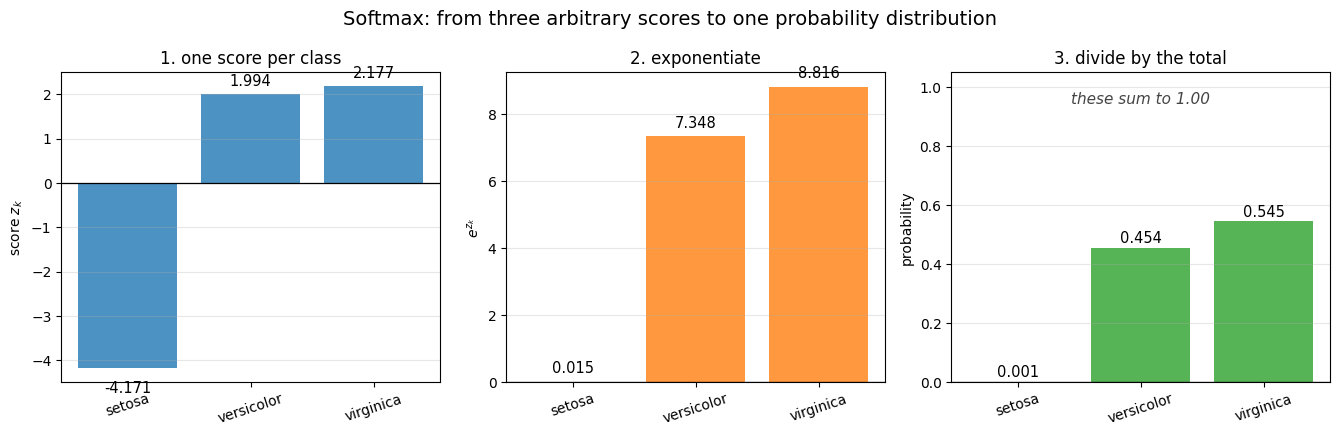

In [20]:
flower = 70                                     # a genuinely ambiguous one
scores = multi.decision_function(X_all_species.iloc[[flower]])[0]
exponentials = np.exp(scores)
probabilities = exponentials / exponentials.sum()

names = list(multi.classes_)
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4))

panels = [
    (scores,        "1. one score per class",       "score $z_k$",      "tab:blue",   None),
    (exponentials,  "2. exponentiate",              "$e^{z_k}$",        "tab:orange", None),
    (probabilities, "3. divide by the total",       "probability",      "tab:green",  (0, 1.05)),
]

for ax, (values, title, ylabel, colour, ylim) in zip(axes, panels):
    bars = ax.bar(names, values, color=colour, alpha=0.8)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(ylabel)
    ax.axhline(0, color="black", linewidth=0.9)
    if ylim:
        ax.set_ylim(*ylim)
    for bar, value in zip(bars, values):
        offset = 0.03 * (max(values) - min(0, min(values)))
        ax.text(bar.get_x() + bar.get_width()/2,
                value + (offset if value >= 0 else -offset * 3),
                f"{value:.3f}", ha="center", fontsize=10.5)
    ax.tick_params(axis="x", rotation=18)
    ax.grid(alpha=0.3, axis="y")

axes[2].text(0.5, 0.90, f"these sum to {probabilities.sum():.2f}", transform=axes[2].transAxes,
             ha="center", fontsize=11, style="italic", color="#444")

fig.suptitle("Softmax: from three arbitrary scores to one probability distribution", fontsize=14)
plt.tight_layout()
plt.show()

Notice what each step accomplishes.

The scores in the first panel are meaningless on their own — one is around $-4$, which cannot be a
probability of anything. After exponentiating, all three are positive, and the class that had the
highest score still has the largest value. After normalising, they sum to exactly 1.

Note also that only the **differences** between scores matter. Adding the same constant to all
three would multiply every exponential by the same factor, which cancels in the division. That is
why implementations subtract the largest score before exponentiating: it prevents overflow without
changing the answer at all.

In [21]:
# scikit-learn's predict_proba does exactly the calculation above
print("computed by hand:    ", probabilities.round(4))
print("predict_proba:       ", multi.predict_proba(X_all_species.iloc[[flower]])[0].round(4))
print("identical:           ", np.allclose(probabilities, multi.predict_proba(X_all_species.iloc[[flower]])[0]))

# adding a constant to every score changes nothing
shifted = np.exp(scores + 100.0) / np.exp(scores + 100.0).sum()
print("\nafter adding 100 to every score:", shifted.round(4))

computed by hand:     [0.001  0.4542 0.5449]
predict_proba:        [0.001  0.4542 0.5449]
identical:            True

after adding 100 to every score: [0.001  0.4542 0.5449]


## 10.3 Softmax is the sigmoid, generalised

The two-class case is not a separate method. With $K = 2$, softmax reduces to the sigmoid from
section 3, exactly.

Writing the softmax probability of class 2 and dividing top and bottom by $e^{z_1}$:

$$
\hat{p}_2 \;=\; \frac{e^{z_2}}{e^{z_1} + e^{z_2}}
\;=\; \frac{1}{1 + e^{-(z_2 - z_1)}}
\;=\; \sigma(z_2 - z_1)
$$

which is precisely the sigmoid applied to the difference of the two scores. So everything learned
in sections 3 to 7 is the special case $K = 2$.

In [22]:
two_scores = np.array([0.0, 1.7])

softmax_result = np.exp(two_scores) / np.exp(two_scores).sum()

print(f"softmax([0, 1.7]), probability of the second class: {softmax_result[1]:.6f}")
print(f"sigmoid(1.7 - 0)                                  : {sigmoid(1.7):.6f}")

softmax([0, 1.7]), probability of the second class: 0.845535
sigmoid(1.7 - 0)                                  : 0.845535


## 10.4 Fitting it, and reading the result

Nothing changes in the code. `LogisticRegression` detects that the target has more than two values
and fits the multiclass model automatically.

In [23]:
print(f"accuracy on all three species: {accuracy_score(y_all_species, multi.predict(X_all_species)):.3f}")

print(f"\nflower {flower}, whose true species is '{y_all_species.iloc[flower]}':")
print(pd.Series(multi.predict_proba(X_all_species.iloc[[flower]])[0], index=multi.classes_).round(3))
print(f"\npredicted: {multi.predict(X_all_species.iloc[[flower]])[0]}")

accuracy on all three species: 0.967

flower 70, whose true species is 'versicolor':
setosa        0.001
versicolor    0.454
virginica     0.545
dtype: float64

predicted: virginica


This particular flower is worth dwelling on, because the model **gets it wrong**.

Its true species is versicolor, and the model puts slightly more probability on virginica: 0.545
against 0.454. Since `predict` returns whichever is largest, it reports virginica.

Look at what the probabilities say, though. The model is not confident. It is reporting something
close to a coin flip between two species, and it is right to — this flower sits in the overlap
region we saw in section 7. A model that had claimed virginica with probability 0.99 would have
been wrong *and* misleading.

This is the practical argument for reading `predict_proba` rather than `predict`. The single
predicted label discards exactly the information that would have told you not to trust it.

## 10.5 What the decision regions look like

With one score per class, the prediction is whichever score is largest. Two classes swap places
where their scores are equal, and since both scores are linear in the features, that boundary is a
straight line.

So the feature plane is carved into regions by straight boundaries — one for each pair of classes
that actually meets.

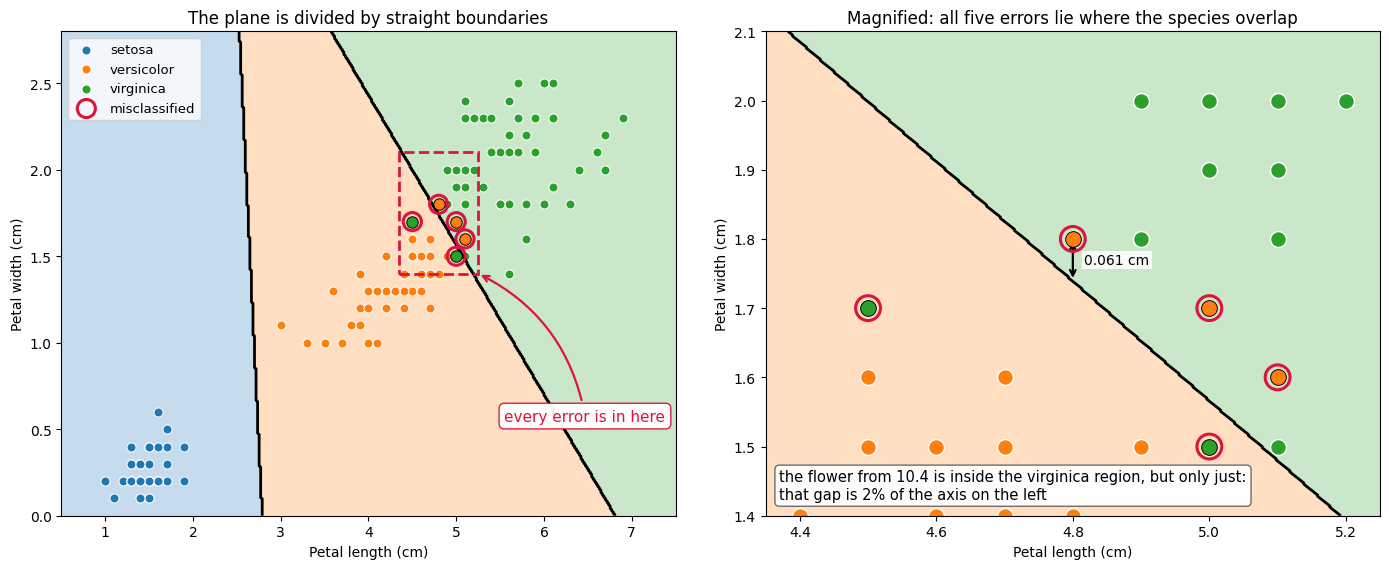

In [24]:
lengths = np.linspace(0.5, 7.5, 400)
widths = np.linspace(0.0, 2.8, 400)
LL, WW = np.meshgrid(lengths, widths)
mesh = pd.DataFrame({"petal_length": LL.ravel(), "petal_width": WW.ravel()})

predicted_index = np.array([list(multi.classes_).index(name) for name in multi.predict(mesh)])

region_colours = ["tab:blue", "tab:orange", "tab:green"]
colour_of = dict(zip(multi.classes_, region_colours))

# Every flower the model gets wrong, and the species it actually is.
errors = iris[multi.predict(X_all_species) != y_all_species]

window = {"left": 4.35, "right": 5.25, "bottom": 1.40, "top": 2.10}
fig, (wide, zoom) = plt.subplots(1, 2, figsize=(14, 5.8))


def draw_regions(ax, length_range, width_range):
    """Shade the predicted species across a rectangle of the feature plane."""
    grid_l, grid_w = np.meshgrid(length_range, width_range)
    frame = pd.DataFrame({"petal_length": grid_l.ravel(), "petal_width": grid_w.ravel()})
    labels = np.array([list(multi.classes_).index(n)
                       for n in multi.predict(frame)]).reshape(grid_l.shape)
    ax.contourf(grid_l, grid_w, labels, levels=[-0.5, 0.5, 1.5, 2.5],
                colors=region_colours, alpha=0.25)
    ax.contour(grid_l, grid_w, labels, levels=[0.5, 1.5], colors="black", linewidths=2)
    return grid_w, labels


def mark_errors(ax, size):
    """Ring each misclassified flower, with a dot inside in its TRUE species colour."""
    ax.scatter(errors["petal_length"], errors["petal_width"], s=size, facecolor="none",
               edgecolor="crimson", linewidth=2.2, zorder=6, label="misclassified")
    for _, row in errors.iterrows():
        ax.scatter(row["petal_length"], row["petal_width"], s=size * 0.40,
                   color=colour_of[row["species"]], edgecolor="black",
                   linewidth=0.7, zorder=7)


# ---- left panel: the whole feature plane -------------------------------------------
draw_regions(wide, lengths, widths)
for name, group in iris.groupby("species"):
    wide.scatter(group["petal_length"], group["petal_width"], s=42,
                 edgecolor="white", linewidth=0.7, label=name)
mark_errors(wide, 170)

wide.add_patch(plt.Rectangle((window["left"], window["bottom"]),
                             window["right"] - window["left"],
                             window["top"] - window["bottom"],
                             facecolor="none", edgecolor="crimson",
                             linewidth=2.0, linestyle="--", zorder=5))
wide.annotate("every error is in here", xy=(window["right"], window["bottom"]),
              xytext=(5.55, 0.55), fontsize=11, color="crimson",
              bbox={"facecolor": "white", "edgecolor": "crimson",
                    "boxstyle": "round,pad=0.35", "alpha": 0.95},
              arrowprops={"arrowstyle": "->", "color": "crimson", "linewidth": 1.6,
                          "connectionstyle": "arc3,rad=0.25"})

wide.set_xlabel("Petal length (cm)")
wide.set_ylabel("Petal width (cm)")
wide.set_title("The plane is divided by straight boundaries")
wide.legend(loc="upper left", fontsize=9.5)

# ---- right panel: the contested band, magnified -------------------------------------
zoom_lengths = np.linspace(window["left"], window["right"], 400)
zoom_widths = np.linspace(window["bottom"], window["top"], 400)
grid_w, zoom_labels = draw_regions(zoom, zoom_lengths, zoom_widths)

for name, group in iris.groupby("species"):
    zoom.scatter(group["petal_length"], group["petal_width"], s=130,
                 edgecolor="white", linewidth=1.0)
mark_errors(zoom, 320)

# How far past the boundary does the flower from section 10.4 actually sit?
length, width = X_all_species.iloc[flower]
column = np.abs(zoom_lengths - length).argmin()
crossing = np.nonzero(np.diff(zoom_labels[:, column]))[0][0]
boundary_width = zoom_widths[crossing:crossing + 2].mean()

zoom.annotate("", xy=(length, width), xytext=(length, boundary_width),
              arrowprops={"arrowstyle": "<->", "color": "black", "linewidth": 1.6})
zoom.text(length + 0.017, 0.5 * (width + boundary_width), f"{width - boundary_width:.3f} cm",
          fontsize=10, va="center",
          bbox={"facecolor": "white", "edgecolor": "none", "pad": 1.5, "alpha": 0.85})
zoom.text(window["left"] + 0.02, window["bottom"] + 0.02,
          f"the flower from 10.4 is inside the virginica region, but only just:\n"
          f"that gap is {100 * (width - boundary_width) / 2.8:.0f}% of the axis on the left",
          va="bottom", fontsize=10.5,
          bbox={"facecolor": "white", "edgecolor": "0.4",
                "boxstyle": "round,pad=0.3", "alpha": 0.95})

zoom.set_xlim(window["left"], window["right"])
zoom.set_ylim(window["bottom"], window["top"])
zoom.set_xlabel("Petal length (cm)")
zoom.set_ylabel("Petal width (cm)")
zoom.set_title("Magnified: all five errors lie where the species overlap")

plt.tight_layout()
plt.show()

Each region contains the flowers the model assigns to one species, and every boundary is straight.
Setosa is separated by a wide empty margin, exactly as the exploratory plots in `01C` predicted.

The interesting part is the border between the other two. Each misclassified flower is ringed in
red, with a dot inside showing the species it really is — worth doing, because at this density the
markers overlap and the topmost one wins. All five errors fall inside the dashed box, and the
magnified view shows why: this is where versicolor and virginica genuinely overlap. Eighteen
versicolor lie within the range of petal measurements spanned by virginica.

The flower from section 10.4 is the circled one at the top. At full scale it looks as though the
model placed it correctly, and magnifying it shows why that impression is wrong: it is inside the
virginica region, but by six hundredths of a centimetre — about two per cent of the left-hand axis,
far too small to see there. That tiny margin is the whole of the difference between 0.545 and 0.454.

Two conclusions follow, and they point in different directions.

A more flexible boundary — one allowed to bend around individual flowers — could capture most of
these five. Whether it *should* is the subject of `02C`, and the answer is usually no.

But no boundary of any shape captures all of them, because the overlap is real: in this
two-dimensional space, some versicolor and some virginica are simply not distinguishable. That
floor cannot be lowered by changing the model, only by measuring something else. Class 3 gives it a
name.

## 10.6 The alternative: one-vs-rest

Softmax is not the only option. **One-vs-rest** fits $K$ *separate* binary classifiers — "setosa or
not", "versicolor or not", "virginica or not" — and predicts whichever reports the highest
confidence.

It is simpler, and it works with any binary classifier at all, which is why it is still used. But
its scores come from models that were fitted independently, so they are not a probability
distribution: there is nothing forcing them to sum to one, and they can be mutually inconsistent.

Softmax fits all the classes together in one model, which is why its outputs are coherent — and
why it is the version that became standard in deep learning.

> Every classification network you meet from Class 7 onward ends in a softmax layer. It is the same
> function, applied to scores computed by something far more elaborate than a linear model.

<div class="alert alert-success">
<b>Mini-exercise 6 — Reading a multiclass model</b><br>
Using the fitted <code>multi</code> model:
<br><br>
1. Find the flower whose largest predicted probability is the <em>smallest</em> of all 150. Which species is it, and what does the model say?<br>
2. The figure above rings the misclassified flowers. Reproduce that set in code, then report the accuracy on versicolor and virginica alone, with setosa excluded.<br>
3. For each of those, is the largest probability close to 0.5, or is the model confidently wrong?<br>
4. Verify on any flower that subtracting the largest score before exponentiating gives the same probabilities.
</div>

In [25]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

This also answers the question `01C` closed on: a model that predicts the species from the
measurements, and reports how sure it is.

# 11. Common pitfalls

**Fitting a straight line to 0/1 labels.**
It runs, and it produces predictions outside $[0, 1]$ that cannot be read as probabilities.

**Reading `predict` when you wanted `predict_proba`.**
A prediction of "virginica" hides whether the model was certain or was guessing at 0.51.

**Judging a classifier by accuracy alone.**
On imbalanced data, predicting the majority class always looks excellent. Look at the confusion
matrix.

**Assuming 0.5 is the right threshold.**
It is a default, not a law. The right threshold depends on the relative cost of the two mistakes.

**Reading logistic coefficients as effects.**
The same instability from correlated features that `02A` §8.4 showed for linear regression applies
here.

**Expecting a linear model to find a curved boundary.**
It cannot. That is a property of the model, not a failure of the fitting.

**Evaluating on the training data.**
Every accuracy in this notebook was measured on the same flowers the model was fitted to. That is
the subject of the next notebook, and it matters more than anything else here.

# 12. Final exercises

<div class="alert alert-success">
<b>Exercise 1 — A different pair of species</b><br>
Repeat the one-feature analysis for <code>setosa</code> versus <code>versicolor</code>.
<br><br>
1. Fit a logistic regression on <code>petal_length</code>.<br>
2. What accuracy do you get, and where is the decision boundary?<br>
3. Plot the fitted probability curve. How does its steepness compare with the versicolor/virginica curve in section 4?<br>
4. These two species are perfectly separable. What does that do to the fitted slope, and why?
</div>

In [26]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 2 — Rescuing the rings</b><br>
The concentric rings in section 9 defeat a straight boundary in <code>(x1, x2)</code>. Fix it by
changing the representation.
<br><br>
1. Build a new feature <code>r_squared = x1**2 + x2**2</code>.<br>
2. Fit a logistic regression using that single feature.<br>
3. What accuracy do you obtain?<br>
4. Where is the decision boundary in terms of <code>r_squared</code>, and what radius does that correspond to?<br>
5. The model is still a linear classifier. Explain, in one sentence, why it now works.
</div>

In [27]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 3 — The cost of a mistake</b><br>
A detector classifies events as signal or background. Signal events are rare: 2 in every 1000.
<br><br>
1. What accuracy does a model that always predicts "background" achieve?<br>
2. Sketch the confusion matrix for that model on 10,000 events.<br>
3. Which entry of the matrix does a physicist searching for a new particle care most about?<br>
4. Would you set the threshold above or below 0.5? What does that cost you?
</div>

In [28]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# Key Takeaways

- Classification differs from regression only in the target. The learning loop is unchanged; the
  model must output a probability, and the loss changes accordingly.
- Fitting a straight line to 0/1 labels gives predictions outside $[0, 1]$ that cannot be read as
  probabilities.
- The logistic function maps any real number into $(0, 1)$, equals 0.5 at zero, and saturates.
- Logistic regression computes a linear score and passes it through the sigmoid. It is a
  classification method despite the name.
- Cross-entropy is maximum likelihood under a **Bernoulli** assumption, exactly as squared error is
  maximum likelihood under a **Gaussian** one. The loss follows from what the target is.
- Cross-entropy is convex in the parameters; squared error with a sigmoid is not.
- Being confidently wrong is punished without bound. Being unsure is punished mildly.
- The decision boundary sits where the score is zero: a point with one feature, a line with two, a
  hyperplane in general. That flatness is the model's inductive bias.
- Accuracy alone is not a sufficient measure, particularly when the classes are imbalanced.

# Optional preparation for the next notebook

Before the next notebook, students should be comfortable with:

- the difference between `predict` and `predict_proba`;
- what a decision boundary is, and why logistic regression's is flat;
- why the choice of loss follows from the type of the target;
- reading a confusion matrix.

Every number quoted in this notebook was measured on the same data the model was fitted to. The
model has, in effect, been marking its own homework.

Notebook `02C` asks what happens when we stop letting it, and that question turns out to govern
almost everything that follows in the course.